# Data Exploration

Explores the processed daily hires dataset (see `01_data_prep.ipynb`):
overall trend/seasonality and feature correlations, ahead of modelling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

processed_dir = Path("..") / "data" / "processed"

df = pd.read_csv(processed_dir / "daily_hires_with_holidays.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df.shape

(5877, 12)

## Overview

In [2]:
df.describe()

,date,cycle_hire_count,day_of_week,month,year,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28
count,5877,5877.000000,5877.000000,5877.000000,5877.000000,5876.000000,5870.000000,5849.000000,5870.000000,5849.000000
mean,2018-08-15 00:00:00,26212.886507,3.000510,6.530883,2018.119789,26214.041525,26215.222147,26205.915883,26226.125602,26252.430116
min,2010-07-30 00:00:00,0.000000,0.000000,1.000000,2010.000000,0.000000,0.000000,0.000000,5373.428571,8256.964286
25%,2014-08-07 00:00:00,19969.000000,1.000000,4.000000,2014.000000,19969.750000,19969.250000,19949.000000,20854.071429,20877.035714
50%,2018-08-15 00:00:00,26093.000000,3.000000,7.000000,2018.000000,26093.500000,26095.500000,26083.000000,25651.500000,25889.142857
75%,2022-08-23 00:00:00,32163.000000,5.000000,10.000000,2022.000000,32164.500000,32175.000000,32177.000000,31341.071429,31283.821429
max,2026-08-31 00:00:00,73094.000000,6.000000,12.000000,2026.000000,73094.000000,73094.000000,73094.000000,51915.428571,44868.357143
std,NaN,9226.918281,2.000468,3.440975,4.661220,9227.278610,9230.119963,9243.625707,7758.447568,7204.240534


In [3]:
df["is_bank_holiday"].value_counts()

is_bank_holiday
False    5743
True      134
Name: count, dtype: int64

## Daily hires over time

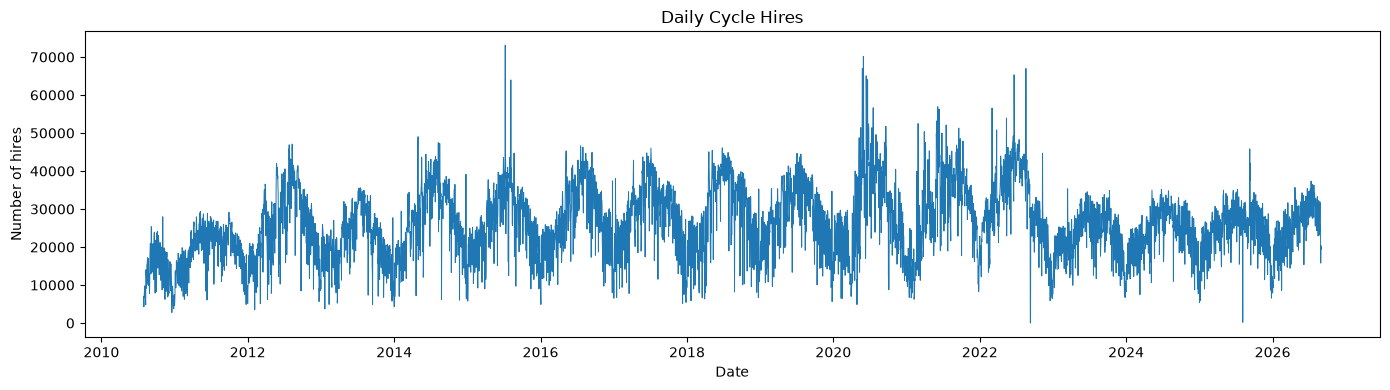

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["cycle_hire_count"], linewidth=0.7)
ax.set_title("Daily Cycle Hires")
ax.set_xlabel("Date")
ax.set_ylabel("Number of hires")
plt.tight_layout()
plt.show()

## Seasonality: hires by day of week and month

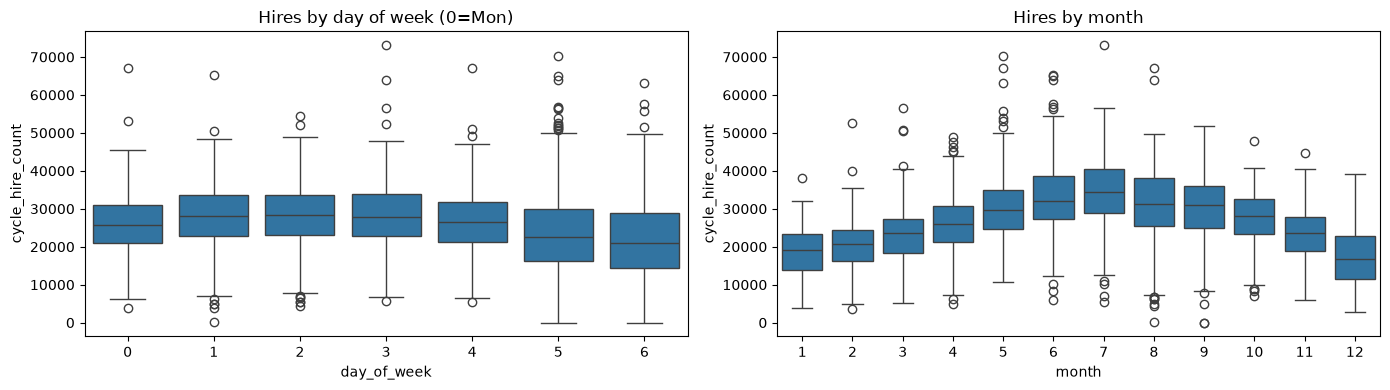

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="day_of_week", y="cycle_hire_count", ax=axes[0])
axes[0].set_title("Hires by day of week (0=Mon)")
sns.boxplot(data=df, x="month", y="cycle_hire_count", ax=axes[1])
axes[1].set_title("Hires by month")
plt.tight_layout()
plt.show()

## Correlation heatmap of numeric features

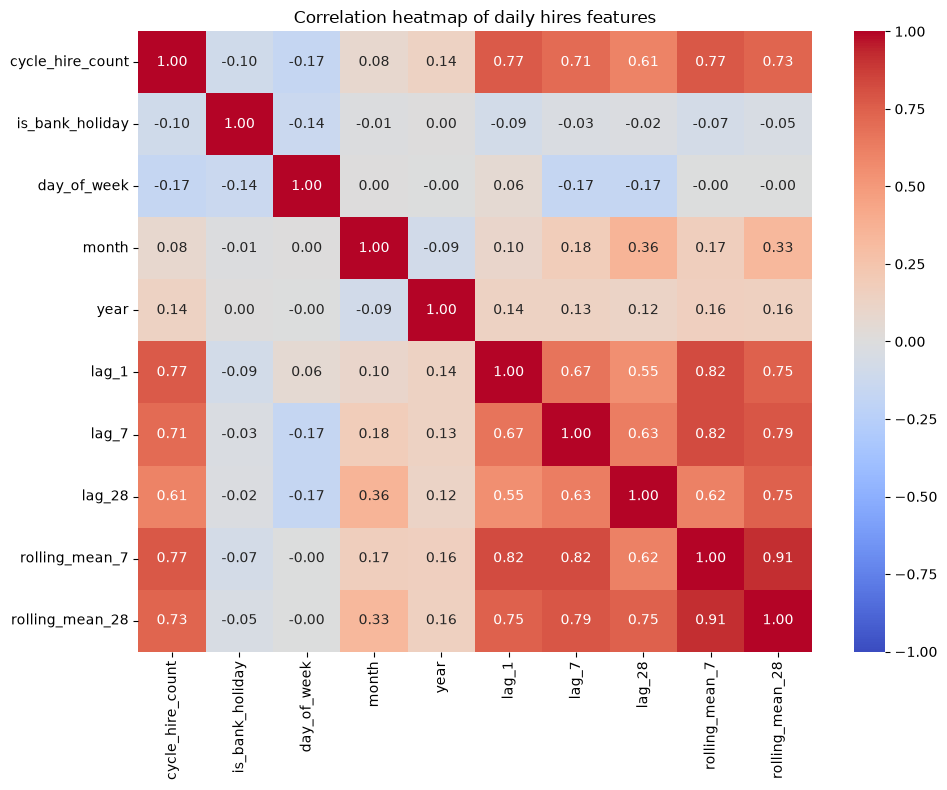

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
)
plt.title("Correlation heatmap of daily hires features")
plt.tight_layout()
plt.show()